In [53]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [54]:
##1.Data Loading
import pandas as pd
df=pd.read_csv(
    "../data/e-shop clothing 2008.csv",
    sep=";"
)
df.head()
df.shape
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

,year,month,day,order,country,session ID,page 1 (main category),colour,location,model photography,price,price 2,page
count,165474.0,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000
mean,2008.0,5.585887,14.524554,9.817476,26.952621,12058.417056,2.400842,6.227655,3.258198,1.260071,43.802507,1.488167,1.710166
std,0.0,1.328160,8.830374,13.478411,7.150691,7008.418903,1.144420,4.235606,1.713206,0.438674,12.548131,0.499861,0.982412
min,2008.0,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,29.000000,5931.000000,1.000000,3.000000,2.000000,1.000000,33.000000,1.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,29.000000,11967.500000,2.000000,4.000000,3.000000,1.000000,43.000000,1.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,29.000000,18219.000000,3.000000,9.000000,5.000000,2.000000,52.000000,2.000000,2.000000
max,2008.0,8.000000,31.000000,195.000000,47.000000,24026.000000,4.000000,14.000000,6.000000,2.000000,82.000000,2.000000,5.000000


## 1.数据集介绍

该数据集来自一个在线服装购物网站，记录了2008年用户在网站上的浏览行为。

数据以用户的一次点击行为作为一条记录，主要包含：

- 用户访问时间信息
- 用户所在国家
- 用户浏览商品类别
- 商品型号
- 商品价格
- 用户访问路径信息


## 数据规模

数据集共包含：

- 165,474 条用户点击记录
- 14 个字段


## 字段说明

|字段|含义|
|-|-|
|year|年份|
|month|月份|
|day|日期|
|order|当天点击顺序|
|country|用户国家编号|
|session ID|用户一次访问的唯一编号|
|page 1|商品主要类别|
|page 2|具体商品型号|
|colour|商品颜色编号|
|location|商品页面位置|
|model photography|商品展示方式|
|price|商品价格|
|price 2|价格等级|
|page|浏览页面编号|


## 数据质量检查

通过数据检查发现：

- 数据共16.5万条记录
- 不存在缺失值
- 除商品型号外，其余字段均为数值类型

后续将进一步分析用户浏览行为和商品偏好。

##  2.用户来源分析

通过统计不同国家编号的访问次数，了解用户主要来源地区。

分析目标：
- 找出访问量最高的国家
- 了解用户来源分布情况

In [55]:

df["country"].value_counts().head(10)

29    133963
9      18003
24      4091
46      2522
44      1385
16       834
21       811
34       716
41       684
3        256
Name: country, dtype: int64

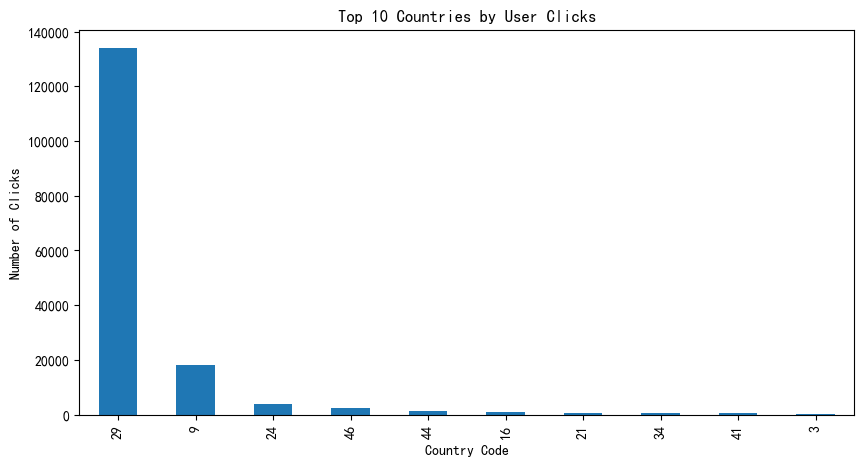

In [ ]:
import matplotlib.pyplot as plt
country_counts = df["country"].value_counts().head(10)

country_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by User Clicks")
plt.xlabel("Country Code")
plt.ylabel("Number of Clicks")
plt.show()

从用户来源分析可以看出，网站访问用户主要集中在少数国家。

其中某一国家编码用户访问量明显高于其他国家，说明该网站用户来源存在明显地域集中现象。

##  3.商品类别分析

通过主要商品类别字段(page 1)，分析用户浏览最多的服装类别。

分析目标：
- 找出热门商品类别
- 了解用户购物偏好

In [57]:
category_counts = df["page 1 (main category)"].value_counts()


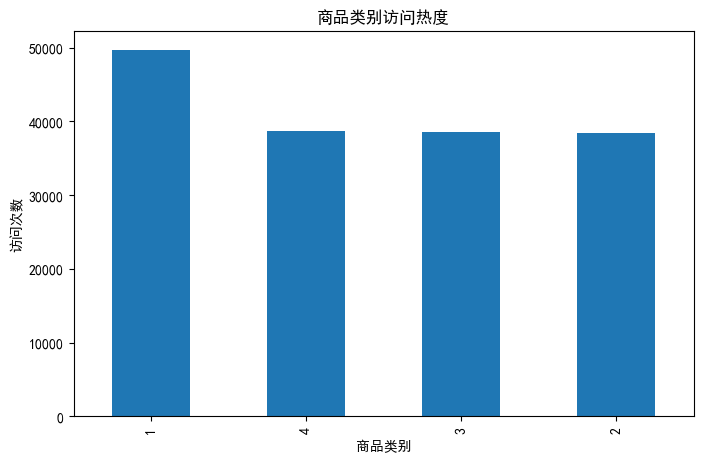

In [58]:
category_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("商品类别访问热度")
plt.xlabel("商品类别")
plt.ylabel("访问次数")

plt.show()

## 4.用户访问行为分析

Session ID代表一次用户访问。

通过分析Session长度，可以了解：

- 用户平均浏览多少商品
- 用户访问深度

In [59]:
session_length = df.groupby("session ID").size()

session_length.describe()

count    24026.000000
mean         6.887289
std          8.995161
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        195.000000
dtype: float64

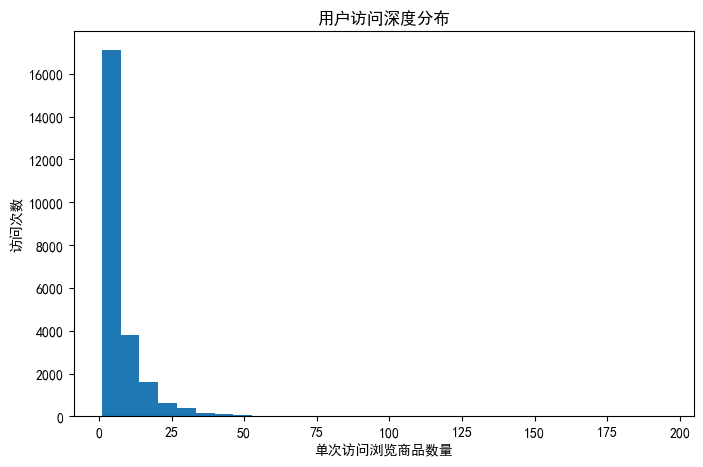

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
session_length.plot(
    kind="hist",
    bins=30,
)
plt.title("用户访问深度分布")
plt.xlabel("单次访问浏览商品数量")
plt.ylabel("访问次数")

plt.show()

结果显示：

- 数据共包含24026次用户访问
- 用户平均一次访问浏览约7个商品
- 大部分用户浏览商品数量集中在较低范围
- 少部分用户存在深度浏览行为，最高达到195次点击

说明大多数用户属于快速浏览用户，而少部分用户具有较高购买兴趣。

In [62]:
top_sessions = (
    session_length
    .sort_values(ascending=False)
    .head(10)
)

top_sessions

session ID
22433    195
13846    192
22902    185
8201     161
19623    142
14191    128
8790     121
19464    120
20660    112
6592     112
dtype: int64

通过分析高频访问用户，可以发现：

- 哪些用户具有较高浏览兴趣
- 是否存在异常高频访问行为
- 为后续用户画像分析提供依据

## 用户访问行为总结

通过Session分析发现：

1. 平均用户一次访问浏览约7个商品；
2. 大部分用户访问深度较浅；
3. 少部分用户存在长时间浏览行为；
4. 用户行为呈现明显的长尾分布特点。

这说明线上购物用户中，普通浏览用户占多数，而深度浏览用户可能具有更高购买意愿。